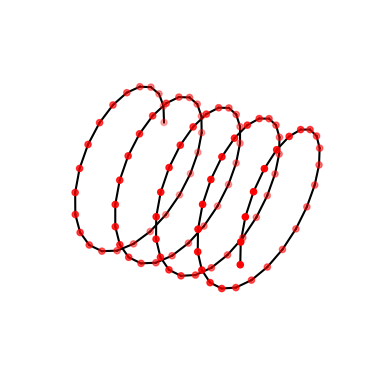

In [1]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=5e-3,
                          shell_h=0)

material = dismech.Material(density=1200,
                            youngs_rod=1e7,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

static_2d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=False,
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-2,
                                  max_iter=25,
                                  total_time=10.0,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
env.add_force('damping', eta=1)

geo = dismech.Geometry.from_txt('../tests/resources/slinky/slinky.txt')

robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

In [2]:
fixed_points = np.array([0, robot.n_nodes-1])
robot = robot.fix_nodes(fixed_points)
stepper = dismech.ImplicitEulerTimeStepper(robot)
robots, t_arr, f_norms = stepper.simulate()
qs = np.stack([robot.state.q for robot in robots])
t_arr = np.array(t_arr)

iter: 1, error: 0.132
iter: 2, error: 0.052
current_time:  0.01
iter: 1, error: 0.244
iter: 2, error: 0.181
current_time:  0.02
iter: 1, error: 0.356
iter: 2, error: 0.394
current_time:  0.03
iter: 1, error: 0.464
iter: 2, error: 0.689
iter: 3, error: 0.000
current_time:  0.04
iter: 1, error: 0.566
iter: 2, error: 1.051
iter: 3, error: 0.001
current_time:  0.05
iter: 1, error: 0.662
iter: 2, error: 1.455
iter: 3, error: 0.002
iter: 4, error: 0.000
current_time:  0.060000000000000005
iter: 1, error: 0.753
iter: 2, error: 1.875
iter: 3, error: 0.003
iter: 4, error: 0.000
current_time:  0.07
iter: 1, error: 0.839
iter: 2, error: 2.287
iter: 3, error: 0.004
iter: 4, error: 0.000
current_time:  0.08
iter: 1, error: 0.918
iter: 2, error: 2.668
iter: 3, error: 0.006
iter: 4, error: 0.000
current_time:  0.09
iter: 1, error: 0.990
iter: 2, error: 3.006
iter: 3, error: 0.007
iter: 4, error: 0.001
current_time:  0.09999999999999999
iter: 1, error: 1.055
iter: 2, error: 3.298
iter: 3, error: 0.009

In [3]:
options = dismech.AnimationOptions(title='Hexli (N=106)', plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()

In [4]:
# get centerline trajectory
data = np.load("slinky_top_bottom_L.npz")

top_nodes_idx = data["top_nodes_idx"]
bottom_nodes_idx = data["bottom_nodes_idx"]
slinky_len = data["L"]

top_nodes_traj = qs[:,robot.map_node_to_dof(top_nodes_idx).flatten()]
bottom_nodes_traj = qs[:,robot.map_node_to_dof(bottom_nodes_idx).flatten()]


centerline_nodes_traj = 0.5*(top_nodes_traj+bottom_nodes_traj)

# append fixed nodes [0,0,0] to the start of the centerline traj and [L,0,0] to its end for all timesteps
T = qs.shape[0]

start_block = np.tile([0.0, 0.0, 0.0], (T, 1))   # (T,3)
end_block   = np.tile([slinky_len, 0.0, 0.0], (T, 1))  # (T,3)

centerline_nodes_traj = np.hstack([
    start_block,
    centerline_nodes_traj,
    end_block
])
print("centerline dof shape after appending start and end fixed nodes: ", centerline_nodes_traj.shape)

# save the centerline trajectory
np.savez("slinky_centerline_truth.npz", centerline_nodes_traj)


centerline dof shape after appending start and end fixed nodes:  (1002, 21)
